<a href="https://colab.research.google.com/github/Kavya-0228/DS_skill/blob/main/DS_SKILL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("Q28_crop_disease.csv")

print(df.head())

  observation_id crop_type  humidity_percent  temperature_c  \
0         AG0001     Maize              79.9           37.2   
1         AG0002      Rice              80.8           20.5   
2         AG0003    Tomato              62.5           30.6   
3         AG0004     Wheat              44.0           25.7   
4         AG0005      Rice              61.1           33.6   

   soil_moisture_percent disease_status  
0                   87.2        Disease  
1                   88.7        Healthy  
2                   79.5        Healthy  
3                   67.6        Healthy  
4                   26.5        Healthy  


In [2]:
# Check missing values
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

print(df.shape)

observation_id           0
crop_type                2
humidity_percent         0
temperature_c            1
soil_moisture_percent    0
disease_status           0
dtype: int64
(117, 6)


In [3]:
print(pd.crosstab(df["crop_type"], df["disease_status"]))

disease_status  Disease  Healthy
crop_type                       
Cotton                1       21
Maize                 9       15
Rice                  3       24
Tomato                2       23
Wheat                 1       18


In [4]:
df["soil_moisture_group"] = pd.cut(
    df["soil_moisture_percent"],
    bins=[0, 30, 60, 100],
    labels=["Low", "Medium", "High"]
)

print(df[["soil_moisture_percent",
          "soil_moisture_group"]].head())

   soil_moisture_percent soil_moisture_group
0                   87.2                High
1                   88.7                High
2                   79.5                High
3                   67.6                High
4                   26.5                 Low


In [5]:
df["risk_score"] = (
    df["humidity_percent"] +
    df["temperature_c"] +
    df["soil_moisture_percent"]
) / 3

print(df[["crop_type", "risk_score"]].head())

  crop_type  risk_score
0     Maize   68.100000
1      Rice   63.333333
2    Tomato   57.533333
3     Wheat   45.766667
4      Rice   40.400000


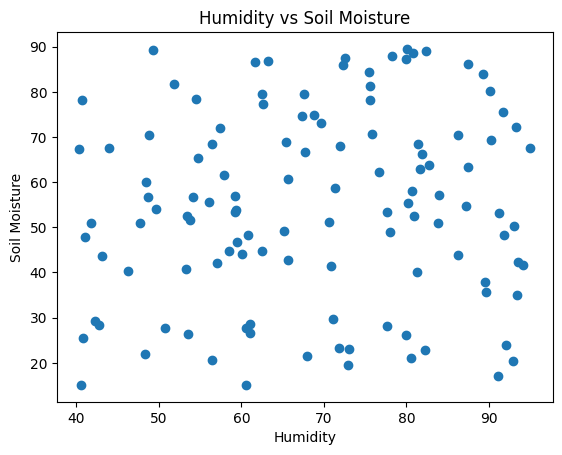

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df["humidity_percent"],
            df["soil_moisture_percent"])

plt.xlabel("Humidity")
plt.ylabel("Soil Moisture")
plt.title("Humidity vs Soil Moisture")
plt.show()

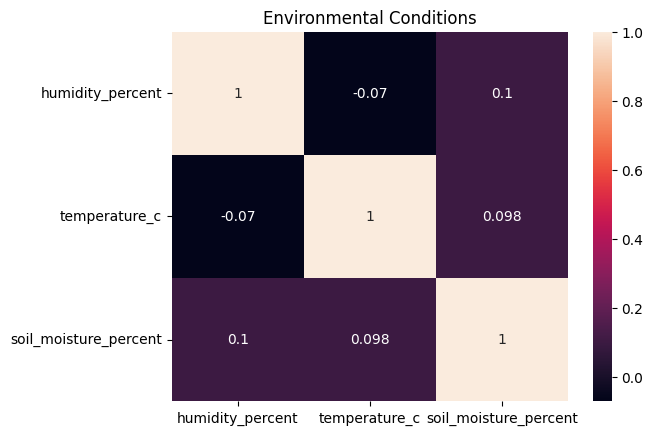

In [7]:
import seaborn as sns

corr = df[[
    "humidity_percent",
    "temperature_c",
    "soil_moisture_percent"
]].corr()

sns.heatmap(corr, annot=True)
plt.title("Environmental Conditions")
plt.show()